<a href="https://colab.research.google.com/github/SMC-AAU-CPH/ML-For-Beginners/blob/main/7-EdgeImpulse/MLME24_Assignment_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Object Detection with Bounding Boxes: Summary of the experiments

For this assignment, I selected the "Object detection with bounding boxes" tutorial from Edge Impulse. The goal was to train and compare three different impulses using the same dataset, adjusting model type and hyperparameters to optimize performance.

In my case, I created a dataset consisted of 66 images (42 mugs and 43 lamps) divided into 77% training and 23% testing.

Using this dataset I created the following three impulses with different configuration:

#### Impulse 1: Tutorial
This first experiment was based on the Edge Impulse object detection tutorial, but using my own dataset.
- Image input: 320x320 RGB
- Model: MobileNetV2 SSD FPN-Lite (320x320)
- Training cycles: 25
- Learning rate: 0.15

#### Impulse 2: EON Tuner optimized model
This impulse was automatically configured using EON Tuner function, which searched for a more efficient balance between latency and accuracy.
- Image input: 160x160 RGB
- Model: FOMO (Faster Objects, More Objects) MobileNetV2 0.1
- Training cycles: 40
- Learning rate: 0.1

#### Impulse 3: Custome model
Based on the insights from the previous experiments, I created a third impulse manually.
- Image size: 320x320 RGB
- Model: MobileNetV2 SSD FPN-Lite (320x320)
- Training cycles: 35
- Learning rate: 0.05

This three experiments achieved the following results:

![alt text](<MLME Experiments Object detection with bounding boxes.png>)

As we can see, the obtained results are quite satisfactory considering the small size of the dataset, but maybe that is just what make this results such a good. However, the third impulse achieved a validation accuracy that may suggest a clear case of overfitting, as the model might have memorized the training data rather than learning to generalize.

To explore this I increased the dataset to 101 images (63 mugs and 54 lamps) and retrained each model using the same hypermarameters to observe how performance changes. After the retraining, the results were the following:

![alt text](<MLME Experiments 2.png>)

These new results show that the third impulse still performs best overall, but the improvement after dataset expansion indicates that the model benefits from more diverse data. Moreover, the significant changes in accuracy for the other two impulses confirm the importance of dataset size and variety in achieving reliable object detection models.

In [1]:
import tensorflow as tf
import numpy as np
import os
import json

# Tutorial 1: Continous Motion Recognition
The project [https://studio.edgeimpulse.com/public/14299/latest](https://studio.edgeimpulse.com/public/14299/latest)

In [2]:
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=412593
DSP_ID=31
LRN_ID=35

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data1'):
    os.makedirs('data1')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data1/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data1/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data1/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data1/Y_split_test.npy


In [3]:
# THE MODEL
if not os.path.exists('model1'):
    os.makedirs('model1')
!wget https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/learn-data/$LRN_ID/model/tflite-h5 -O model1/model1.zip

# unzip model1.zip quitely as model1.h5 and remove model1.zip
!cd model1 && unzip -q model1.zip
!rm model1/model1.zip
!cd ..

--2025-10-22 13:05:52--  https://studio.edgeimpulse.com/v1/api/412593/learn-data/35/model/tflite-h5
Resolving studio.edgeimpulse.com (studio.edgeimpulse.com)... 18.173.166.106, 18.173.166.96, 18.173.166.43, ...
Connecting to studio.edgeimpulse.com (studio.edgeimpulse.com)|18.173.166.106|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘model1/model1.zip’

model1/model1.zip       [ <=>                ]   6.05K  --.-KB/s    in 0s      

2025-10-22 13:05:52 (66.5 MB/s) - ‘model1/model1.zip’ saved [6199]



In [27]:
model = tf.keras.models.load_model('model1/model.h5')

In [28]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 20)             │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           210 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_pred (Dense)                  │ (None, 4)              │            44 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,056 (4.13 KB)

 Trainable params: 1,054 (4.12 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [29]:
test_data = np.load('data1/X_split_test.npy')
test_labels = np.load('data1/Y_split_test.npy')

In [32]:
# The labels are in the first column and go like "idle", "snake", "updown", "wave, and "anomaly" or "other"?
test_labels[:,0]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
       5, 5, 5, 5, 5, 5, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
predictions = model.predict(test_data)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [ ]:
np.argmax(predictions, axis = 1)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
# For calculating the accuracy we substract -1 from the test labels and add +1 to the predictions
accuracy = np.mean(1+np.argmax(predictions, axis = 1) == (test_labels[:,0]-1))
print(f'Accuracy: {accuracy * 100: .2f}%')

Accuracy:  97.21%


# Tutorial 2: Responding to Voice

In [ ]:
# The data and model are to be taken from the project page https://studio.edgeimpulse.com/public/14225/latest
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=412592
DSP_ID=25
LRN_ID=5

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data'):
    os.makedirs('data')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data/Y_split_test.npy


In [ ]:
# THE MODEL
!wget https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/learn-data/$LRN_ID/model/tflite-h5 -O model2.zip

# unzip quitely and remove model2.zip
!unzip -q model2.zip
!rm model2.zip
!ls

--2025-10-01 15:28:12--  https://studio.edgeimpulse.com/v1/api/412592/learn-data/5/model/tflite-h5
Resolving studio.edgeimpulse.com (studio.edgeimpulse.com)... 18.173.166.96, 18.173.166.106, 18.173.166.43, ...
Connecting to studio.edgeimpulse.com (studio.edgeimpulse.com)|18.173.166.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘model2.zip’

model2.zip              [ <=>                ]  16.00K  --.-KB/s    in 0.001s  

2025-10-01 15:28:12 (14.6 MB/s) - ‘model2.zip’ saved [16381]

data  data1  model1  model.h5  sample_data


In [ ]:
model = tf.keras.models.load_model('model.h5')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 624)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 48, 13, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 13, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 7, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 7, 8)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 7, 16)      │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 4, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 4, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_pred (Dense)                  │ (None, 3)              │         2,307 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,557 (13.90 KB)

 Trainable params: 3,555 (13.89 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
test_data = np.load('data/X_split_test.npy')
test_labels = np.load('data/Y_split_test.npy')

In [ ]:
# The labels are in the first column and go like 1=helloworld, 2=noise, 3=unknown
test_labels[:,0]

array([1, 3, 1, 1, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,

In [ ]:
predictions = model.predict(test_data)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
np.argmax(predictions, axis = 1)

array([0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 0, 1, 2, 2, 1, 2, 0, 0, 2, 2, 2, 2,
       1, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 0, 2, 2,
       0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 1, 2, 2, 1, 2, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
# For calculating the accuracy we substract -1
test_labels[:,0]-1

array([0, 2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
accuracy = np.mean(np.argmax(predictions, axis = 1) == (test_labels[:,0]-1))

In [ ]:
print(f'Accuracy: {accuracy * 100: .2f}%')

Accuracy:  90.80%


# Tutorial 3: Recognize sounds from audio
https://studio.edgeimpulse.com/public/14301/latest

In [ ]:
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=417225
DSP_ID=24
LRN_ID=28

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data3'):
    os.makedirs('data3')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data3/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data3/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data3/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data3/Y_split_test.npy


In [ ]:
# THE MODEL
if not os.path.exists('model3'):
    os.makedirs('model3')
!wget https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/learn-data/$LRN_ID/model/tflite-h5 -O model3/model3.zip

# unzip model1.zip quitely as model1.h5 and remove model1.zip
!cd model3 && unzip -q model3.zip
!rm model3/model3.zip
!cd ..

--2025-10-01 15:28:17--  https://studio.edgeimpulse.com/v1/api/417225/learn-data/28/model/tflite-h5
Resolving studio.edgeimpulse.com (studio.edgeimpulse.com)... 18.173.166.96, 18.173.166.106, 18.173.166.43, ...
Connecting to studio.edgeimpulse.com (studio.edgeimpulse.com)|18.173.166.96|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘model3/model3.zip’

model3/model3.zip       [ <=>                ]  12.99K  --.-KB/s    in 0.001s  

2025-10-01 15:28:18 (18.9 MB/s) - ‘model3/model3.zip’ saved [13298]



In [ ]:
model = tf.keras.models.load_model('model3/model.h5')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 99, 65)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 99, 8)          │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 16)         │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ y_pred (Dense)                  │ (None, 2)              │           802 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,772 (10.83 KB)

 Trainable params: 2,770 (10.82 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [ ]:
test_data = np.load('data3/X_split_test.npy')
test_labels = np.load('data3/Y_split_test.npy')

In [ ]:
test_labels[:,0]

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [ ]:
predictions = model.predict(test_data)
np.argmax(predictions, axis = 1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [ ]:
accuracy = np.mean(np.argmax(predictions, axis = 1) == (test_labels[:,0]-1))
print(f'Accuracy: {accuracy * 100: .2f}%')

Accuracy:  100.00%


# Tutorial 4: Adding sight to your sensors
https://studio.edgeimpulse.com/public/14227/latest

Note that this did not work with tensorflow==2.17.0 so we downgraded to tensorflow==2.12.0. We need to check fresh if this causes problems for other tutorials. Better solution is to retrain the model and save in a newer format, and use the new .h5 instead of the original project. We could easily do this with the cloned version of the project?

**Sensor & Block Information**
- Image data
- Image DSP block for normalizing image files
- Transfer Learning block with prediction outputs: "lamp", "plant", "unknown"

In [ ]:
import tensorflow as tf

In [87]:
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=792097
DSP_ID=31
LRN_ID=19

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data4'):
    os.makedirs('data4')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data4/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data4/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data4/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data4/Y_split_test.npy


In [ ]:
# We work with the Tensorflow Lite (float32) model instead of h5
# Otherwise we need to downgrade TF version
!wget https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/learn-data/$LRN_ID/model/tflite-savedmodel -O model4/model4.zip
!cd model4 && unzip -q model4.zip
!rm model4/model4.zip
!cd ..

In [ ]:
# load the saved_model tflite form the folder not h5
model = tf.keras.layers.TFSMLayer('model4/saved_model', call_endpoint='serving_default')

In [ ]:
test_data = np.load('data4/X_split_test.npy')
test_labels = np.load('data4/Y_split_test.npy')
test_labels[:,0]

array([3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 1, 1, 1, 1, 1, 2, 2, 3, 3, 3, 3, 3, 1, 1, 1, 1, 1, 1,
       1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3], dtype=int32)

In [ ]:
# Reshape test_data to match the expected input shape of the model
test_data = test_data.reshape((-1, 96, 96, 3))

# Get the serving_default signature from the model
# Access the underlying loaded object from TFSMLayer
infer = model._reloaded_obj.signatures['serving_default']

# Run inference using the signature
predictions = infer(tf.constant(test_data, dtype=tf.float32))

# The output key might vary, need to check the model's output signature
# Assuming the output key is 'output_0' based on Tutorial 5A
prediction_results = predictions['output_0'].numpy()

np.argmax(prediction_results, axis = 1)

array([2, 0, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 1, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0])

In [ ]:
# calculate accuracy
predicted_indices = np.argmax(prediction_results, axis = 1)
accuracy = np.mean(predicted_indices == (test_labels[:,0]-1))
print(f'Accuracy: {accuracy * 100: .2f}%')

Accuracy:  85.45%


# TODO Tutorial 5A: Object Detection
https://studio.edgeimpulse.com/public/25483/latest

Since the project involves an embedded devices, Keras h5 model is not created.

Trying with tf_lite


In [14]:
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=795723
DSP_ID=96
LRN_ID=97

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data5a'):
    os.makedirs('data5a')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data5a/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data5a/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data5a/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data5a/Y_split_test.npy

In [15]:
# THE MODEL
if not os.path.exists('model5a'):
    os.makedirs('model5a')
!wget https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/learn-data/$LRN_ID/model/tflite-savedmodel -O model5a/model5a.zip

# unzip model1.zip quitely as model1.h5 and remove model1.zip
!cd model5a && unzip -q model5a.zip
!rm model5a/model5a.zip
!cd ..

--2025-10-23 07:27:47--  https://studio.edgeimpulse.com/v1/api/795723/learn-data/97/model/tflite-savedmodel
Resolving studio.edgeimpulse.com (studio.edgeimpulse.com)... 13.35.130.42, 13.35.130.77, 13.35.130.39, ...
Connecting to studio.edgeimpulse.com (studio.edgeimpulse.com)|13.35.130.42|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/octet-stream]
Saving to: ‘model5a/model5a.zip’

model5a/model5a.zip     [         <=>        ]   9.82M  5.49MB/s    in 1.8s    

2025-10-23 07:27:49 (5.49 MB/s) - ‘model5a/model5a.zip’ saved [10294790]

replace saved_model/fingerprint.pb? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [77]:
# load a TensorFlow SavedModel for example https://studio.edgeimpulse.com/v1/api/408972/learn-data/5/model/tflite-savedmodel
model = tf.saved_model.load('model5a/saved_model')
# model.summary() #No keras model


In [78]:
test_data = np.load('data5a/X_split_test.npy')

In [79]:
# For y, we read the byte file directly witout np.load()
with open('data5a/Y_split_test.npy', 'rb') as f:
    content = f.read()

In [80]:
json_str = content.decode('utf-8')
data = json.loads(json_str)

In [81]:
# Extract the labels
labels = []

for sample in data['samples']:
    for box in sample['boundingBoxes']:
        labels.append(box['label'])

print(labels)

[2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1]


In [82]:
test_data = test_data.reshape((-1, 320, 320, 3))
test_labels = np.array(labels)

In [104]:
infer = model.signatures['serving_default']
print(infer)

ConcreteFunction Input Parameters:
  input (KEYWORD_ONLY): TensorSpec(shape=(1, 320, 320, 3), dtype=tf.float32, name='input')
Output Type:
  Dict[['output_2', TensorSpec(shape=(), dtype=tf.float32, name='output_2')], ['output_1', TensorSpec(shape=(), dtype=tf.float32, name='output_1')], ['output_0', TensorSpec(shape=(), dtype=tf.float32, name='output_0')], ['output_3', TensorSpec(shape=(), dtype=tf.float32, name='output_3')]]
Captures:
  139769288599568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769287396816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769656099280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769287396432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769287396624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769288599376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769656106576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139769656099088: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [98]:
# Convert the input data to a tensor
input_tensor = tf.convert_to_tensor(test_data, dtype=tf.float32)

In [103]:
# Run inference
predictions = infer(input_tensor)
print(predictions)

{'output_2': <tf.Tensor: shape=(), dtype=float32, numpy=0.0>, 'output_1': <tf.Tensor: shape=(), dtype=float32, numpy=0.0>, 'output_0': <tf.Tensor: shape=(), dtype=float32, numpy=0.0>, 'output_3': <tf.Tensor: shape=(), dtype=float32, numpy=0.0>}


In [107]:
# Extract the prediction results
prediction_results = predictions['output_0'].numpy()  # Adjust the key based on your model's output signature
print(prediction_results)

0.0


Initially, the model was downloaded as a TensorFlow SavedModel and loaded using the TensorFlow API (tf.saved_model.load).

However, when inspecting the model's default signature, it retured four scalar outputs (output_0 to output_3), instead of the expected tensors representing object detection results (bounding boxes, labels and confidence scores).

Executing and printing the inference (predictions = infer(input_tensors) we can observe that the output it only produces zeros, meaning that there should be some problem behind the post-processing operations, and probably some information is not exported correctly from the SavedModel.

Therefore, to perform the real inference, I changed the type of model to the TensorFlow Lite float32, because this model includes the complete detection pipeline.

In the following cells I will explain how this is achieved and analyze the output obtained.

First of all let's start by downloading the float32 model from Edge Impulse Studio and import it to the notebook folder.

Then we execute the .lite using the TFLite Interpreter.

In [ ]:
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=795723
DSP_ID=96
LRN_ID=97

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data5a'):
    os.makedirs('data5a')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data5a/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data5a/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data5a/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data5a/Y_s

In [243]:
model = tf.lite.Interpreter(model_path='/content/model5a_float32.lite')

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Once we have the interpreter ready, we should prepare the model memory loading all the input and output tensor definitions.

And also I printed the input and output details to check how the model expects the input data and how the output data should be analyzed.

In [244]:
model.allocate_tensors()

input_details = model.get_input_details()
output_details = model.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_input:0', 'index': 0, 'shape': array([  1, 320, 320,   3], dtype=int32), 'shape_signature': array([  1, 320, 320,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall:1', 'index': 335, 'shape': array([ 1, 10], dtype=int32), 'shape_signature': array([ 1, 10], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0}, 'sparsity_parameters': {}}, {'name': 'StatefulPartitionedCall:3', 'index': 333, 'shape': array([ 1, 10,  4], dtype=int32), 'shape_signature': array([ 1, 10,  4], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=

As we can observe, the model expects an RGB image (3 channels) of size 320x320 (That information coincides with our model in Edge Impulse Studio). Also, it is especified that the model processes on image at a time.

The next part, as well as with the SavedModel part, is to load the test (X and y) data.

In [245]:
# Extract X and y test data:

test_data = np.load('data5a/X_split_test.npy')
test_data = test_data.reshape((-1, 320, 320, 3))

# For y, we read the byte file directly witout np.load()
with open('data5a/Y_split_test.npy', 'rb') as f:
    content = f.read()

# Extract the labels
labels = []

for sample in data['samples']:
    for box in sample['boundingBoxes']:
        labels.append(box['label'])

print(labels)

[2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 1, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1]


Now let's continue with an example. In this step, a single image is selected and prepared for inference. We select the first image from test_data considering that the shape of the image should be (1, 320, 320, 3).

Then we load the image into the model's input tensor using set_tensor()

And finally, we use the function invoke() to run the entire network. This function will perform all the detection operations of the model and it stores the results into the output tensors.

In [246]:
image = 0 # It can be changed from 0 to 23 to check the 24 images in data_test
sample = test_data[image:image+1].astype(np.float32)
model.set_tensor(input_details[0]['index'], sample)
model.invoke()

In order to access the output of the model we are going to use the function get_tensor().

In [247]:
print(model.get_tensor(output_details[0]['index']))
print(model.get_tensor(output_details[1]['index']))
print(model.get_tensor(output_details[2]['index']))
print(model.get_tensor(output_details[3]['index']))

[[0.8319551  0.7757286  0.2897293  0.28928432 0.2769372  0.24601899
  0.20640954 0.14545234 0.1405669  0.13469444]]
[[[0.7099484  0.520395   0.99820447 0.7392414 ]
  [0.11306645 0.18133903 0.39393604 0.5177365 ]
  [0.11236456 0.13096406 0.68933177 0.5360624 ]
  [0.33527565 0.72030413 0.7343044  0.99012053]
  [0.41093475 0.8810574  0.552644   1.0021219 ]
  [0.73610634 0.4672115  0.91381675 0.563825  ]
  [0.41857034 0.89681786 0.53345835 0.9785786 ]
  [0.11021005 0.25239378 0.30889916 0.5082177 ]
  [0.29565966 0.20103396 0.71911037 0.5238392 ]
  [0.71979505 0.49731213 0.895776   0.62388486]]]
[10.]
[[1. 0. 1. 1. 1. 1. 1. 0. 1. 1.]]


As explained before, the .lite model contains all the information of the scores, bounding boxes and labels.

Therefore we need to acces to that information and try to analyze what it is obtained from each output.

In [248]:
scores = model.get_tensor(output_details[0]['index'])
bounding_boxes = model.get_tensor(output_details[1]['index'])
num_detections = model.get_tensor(output_details[2]['index'])
classes = model.get_tensor(output_details[3]['index'])

As we can observe from the previous printing, the model outputs four tensors after inference.
- scores: contain the confidence values for each detection (the higher value the better).
- bounding_boxes: contain the normalized bounding box coordinates for each object.
- num_detections: the model always outputs a maximum of 10 detections, but this output indicates how many of the 10 possible detections are valid.
- classes: provide the label of each detection.

From the get_tensor() output we can observe that for the first image of the data_test, there are two clear objects identified because of the two high score value. And actually, from the classes output we can see that this two objects are classified as two diferent objects (mug and lamp).

Now, and in the end, let's see in a visually way what we are obtaining:

In [257]:
label_name = ""
valid_detections = 0

for i in range(int(num_detections[0])):
  if scores[0][i] >= 0.5:
    label = int(classes[0][i]) + 1
    if label == 1:
      label_name = "lamp"
    elif label == 2:
      label_name = "mug"

    confidence = scores[0][i]
    valid_detections += 1

    print(f"Detected {label_name} with confidence {confidence}")

Detected mug with confidence 0.831955075263977
Detected lamp with confidence 0.7757285833358765


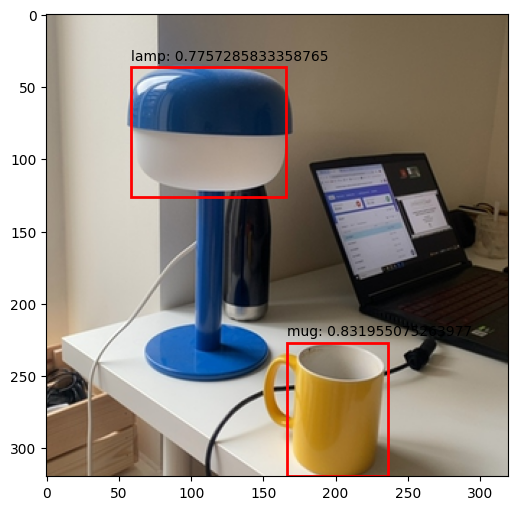

In [259]:
import matplotlib.pyplot as plt

show_image = test_data[image].astype(np.float32)

plt.figure(figsize=(6,6))
plt.imshow(show_image)
ax = plt.gca()

for i in range(int(num_detections[0])):
  if scores[0][i] >= 0.5:
    ymin, xmin, ymax, xmax = bounding_boxes[0][i]
    label = int(classes[0][i]) + 1
    if label == 1:
      label_name = "lamp"
    elif label == 2:
      label_name = "mug"

    ax.add_patch(plt.Rectangle(
      (xmin * show_image.shape[1], ymin * show_image.shape[0]),
      (xmax - xmin) * show_image.shape[1],
      (ymax - ymin) * show_image.shape[0],
      fill=False, color='red', linewidth=2
    ))

    ax.text(xmin * show_image.shape[1], ymin * show_image.shape[0] - 5,
            f"{label_name}: {scores[0][i]}")

plt.show()


Finally as a conclusion I would like to explain that the model was executed without the need for retraining, demostrating that the experiment can be reliably reproduced and assessed offline.

By running inference on the test dataset, we verified that the model output four main tensors, and applying a confidence threshold (0.5) to filter relevant detections we were able to visualize the results drawing bounding boxes, labels and the confidence values on the test images.

Despite the goal of computing the overall model accuracy could not be calculated directly, because the use of the TensorFlow Lite version of the model instead of the SavedModel, the inference and detection results provide the model performance and confirmed its correct functionality.

# TODO Tutorial 5B: Object detection FOMO
https://studio.edgeimpulse.com/public/90393/latest


TODO: the label data must differ being bounding box. Check how to load!!!

TODO: add README



In [32]:
# no cloning needed, the following are extracted from the project page dashboard for auto downloads
PROJECT_ID=90395
DSP_ID=3
LRN_ID=5

# if there is no data subfolder, create one, and get the data inside it; -q flag is for quiet mode

if not os.path.exists('data5b'):
    os.makedirs('data5b')
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/training -O data5b/X_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/training -O data5b/Y_split_train.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/x/testing -O data5b/X_split_test.npy
    !wget -q https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/dsp-data/$DSP_ID/y/testing -O data5b/Y_split_test.npy


In [ ]:
# THE MODEL
if not os.path.exists('model5b'):
    os.makedirs('model5b')
!wget https://studio.edgeimpulse.com/v1/api/$PROJECT_ID/learn-data/$LRN_ID/model/tflite-h5 -O model5b/model5b.zip

# unzip model1.zip quitely as model1.h5 and remove model1.zip
!cd model5b && unzip -q model5b.zip
!rm model5b/model5b.zip
!cd ..

In [ ]:
model = tf.keras.models.load_model('model5b/model.h5')
model.summary()

In [ ]:
test_data = np.load('data5b/X_split_test.npy')
